In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from folium import folium,plugins


In [3]:
DATA_PATH=Path('data/CLEAN_AB_NYC_2019.csv')
df=pd.read_csv(DATA_PATH)
df

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,has_reviews
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,262.0,1
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,48.0,1
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,-1.0,0
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,3.0,1
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,231.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48879,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9,-1.0,0
48880,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36,-1.0,0
48881,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27,-1.0,0
48882,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2,-1.0,0


### NYC map visualization

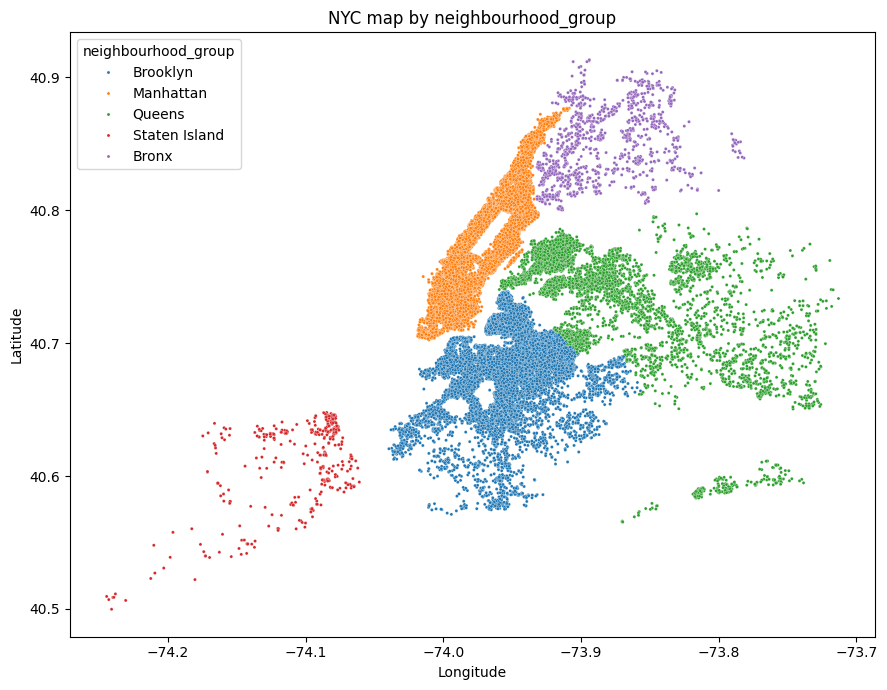

In [4]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df,x='longitude',y='latitude',s=5,hue='neighbourhood_group')
plt.title('NYC map by neighbourhood_group')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

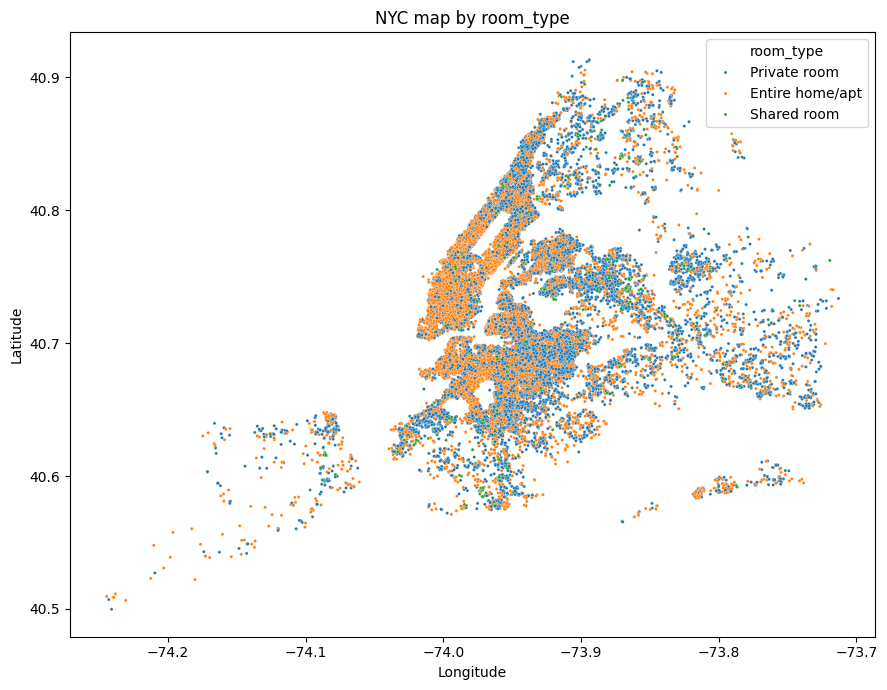

In [5]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df,x='longitude',y='latitude',s=5,hue='room_type')
plt.title('NYC map by room_type')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

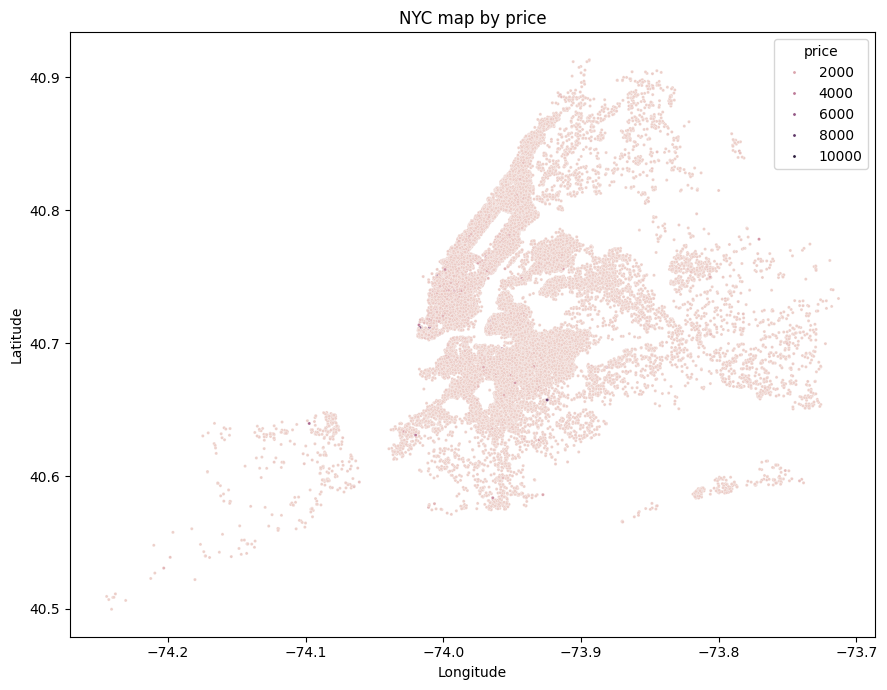

In [6]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df,x='longitude',y='latitude',s=5,hue='price')
plt.title('NYC map by price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

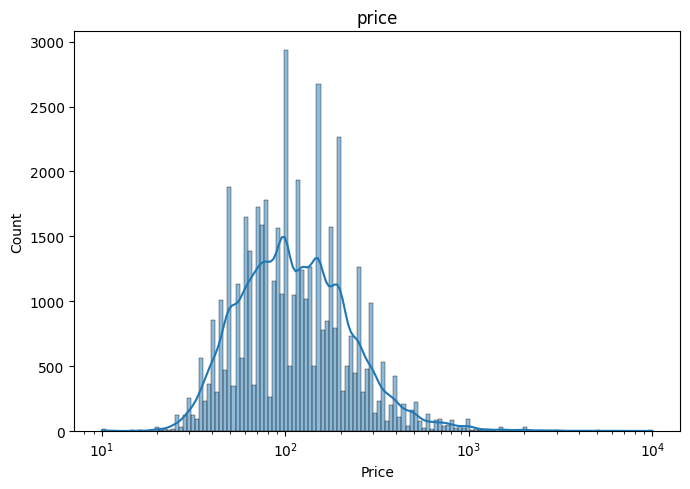

In [7]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='price',kde=True,log_scale=True)
plt.title('price')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

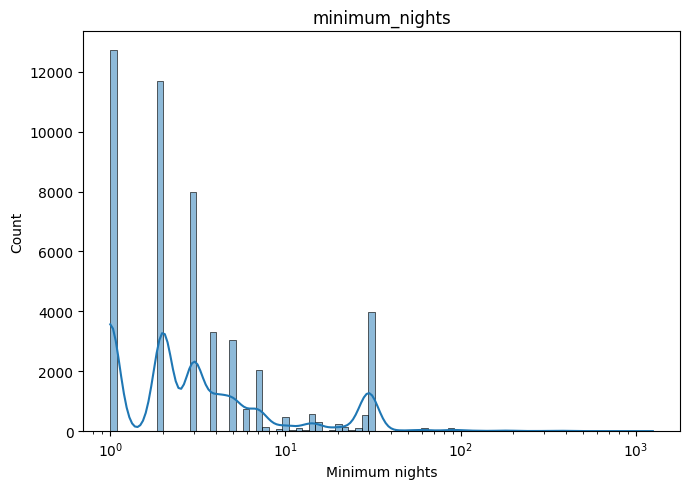

In [8]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='minimum_nights',kde=True,log_scale=True)
plt.title('minimum_nights')
plt.xlabel('Minimum nights')
plt.tight_layout()
plt.show()

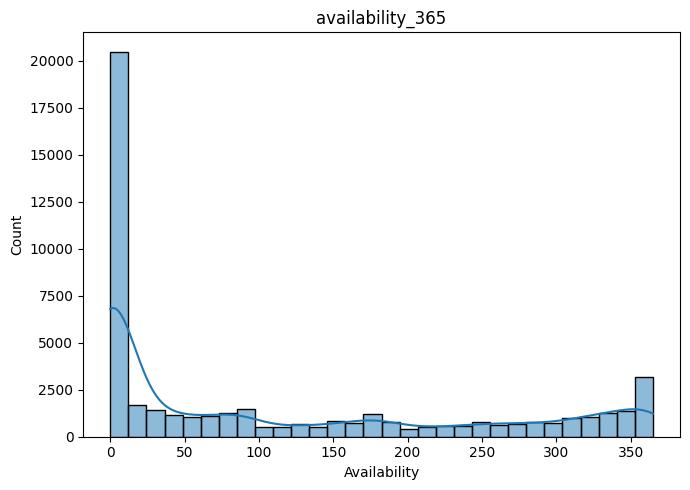

In [9]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='availability_365',kde=True)
plt.title('availability_365')
plt.xlabel('Availability')
plt.tight_layout()
plt.show()

## Price vs room_type / neighbourhood_group 

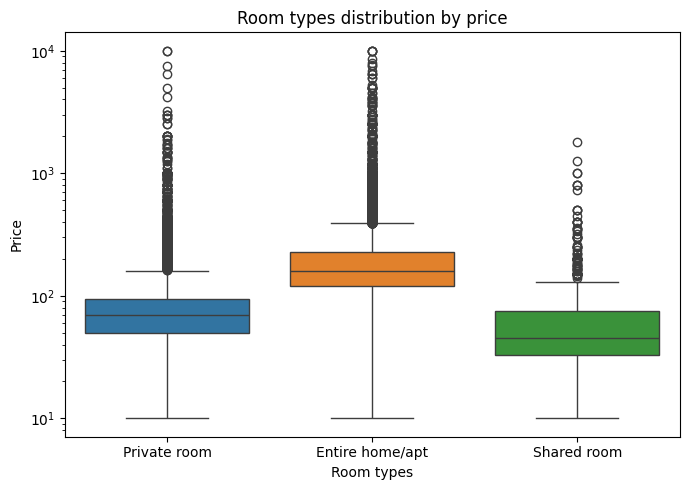

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='room_type', y='price',hue='room_type')
plt.yscale('log')
plt.title('Room types distribution by price')
plt.xlabel('Room types')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

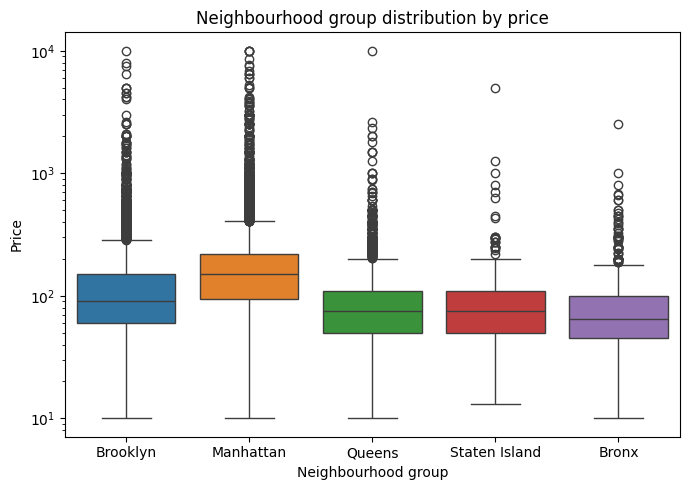

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x='neighbourhood_group',y='price',hue='neighbourhood_group')
plt.yscale('log')
plt.title("Neighbourhood group distribution by price")
plt.xlabel('Neighbourhood group')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

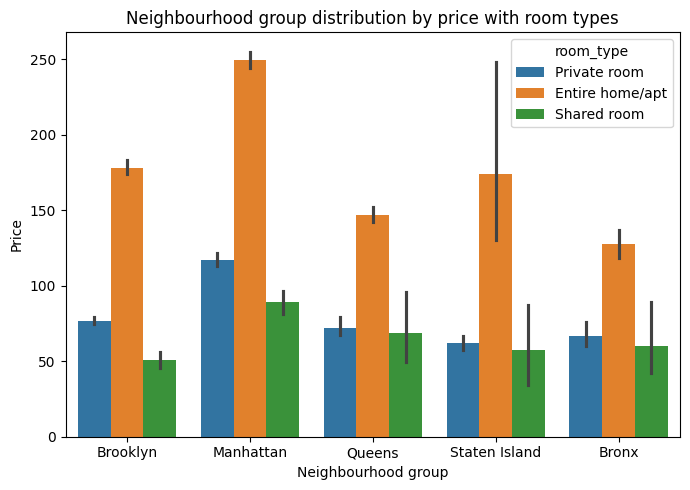

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='neighbourhood_group',y='price',hue='room_type')
plt.title("Neighbourhood group distribution by price with room types")
plt.xlabel('Neighbourhood group')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [13]:
df_num_matrix=df.select_dtypes(include="number")

### Heatmap

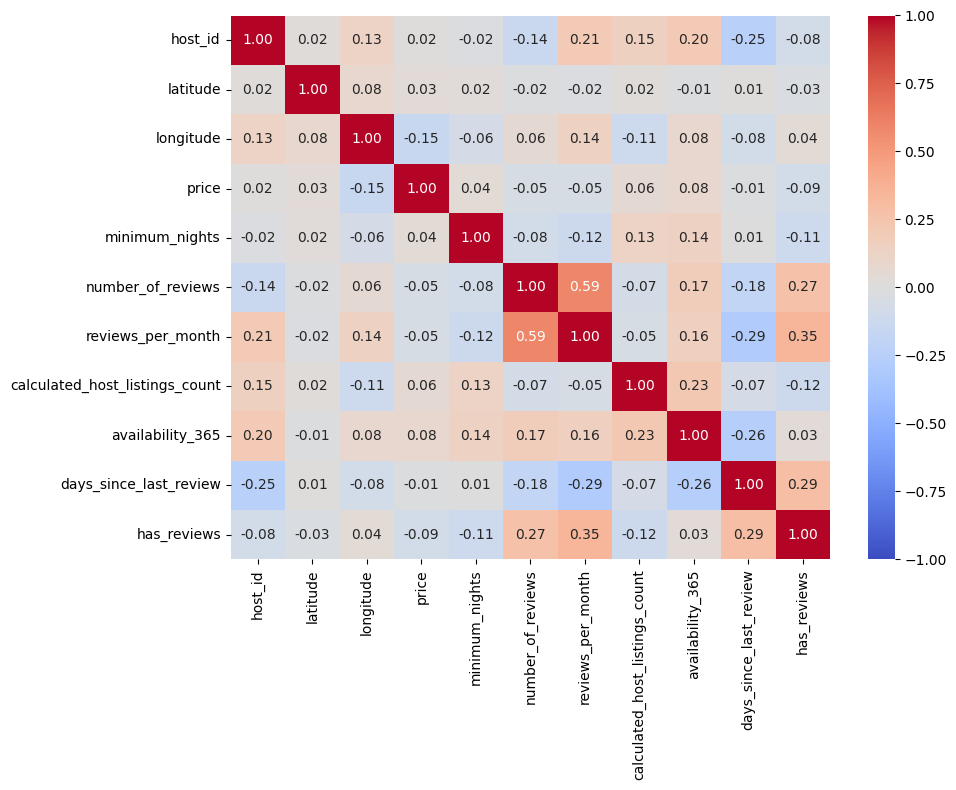

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(data=df_num_matrix.corr(),annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt=".2f")
plt.tight_layout()
plt.show()

### Average price in neighbourhood_group

In [15]:
avg_prices = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
avg_prices

neighbourhood_group
Manhattan        196.884903
Brooklyn         124.438915
Staten Island    114.812332
Queens            99.517649
Bronx             87.577064
Name: price, dtype: float64

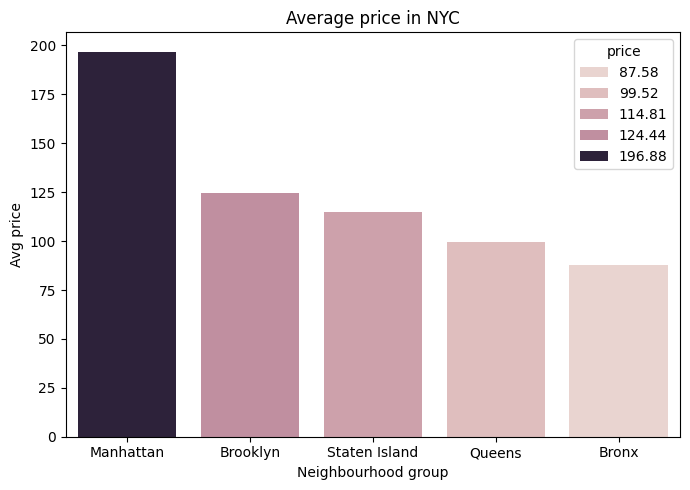

In [16]:
plt.figure(figsize=(7,5))
sns.barplot(x=avg_prices.index, y=avg_prices.values,hue=avg_prices.round(2))
plt.title('Average price in NYC')
plt.xlabel('Neighbourhood group')
plt.ylabel('Avg price')
plt.tight_layout()
plt.show()

### Top/bottom 10 by average price 

In [17]:
neighbourhood_avg_price = df.groupby('neighbourhood')['price'].mean()

top_10_neighbourhood = neighbourhood_avg_price.sort_values(ascending=False).head(10)
bottom_10_neighbourhood = neighbourhood_avg_price.sort_values(ascending=True).head(10)

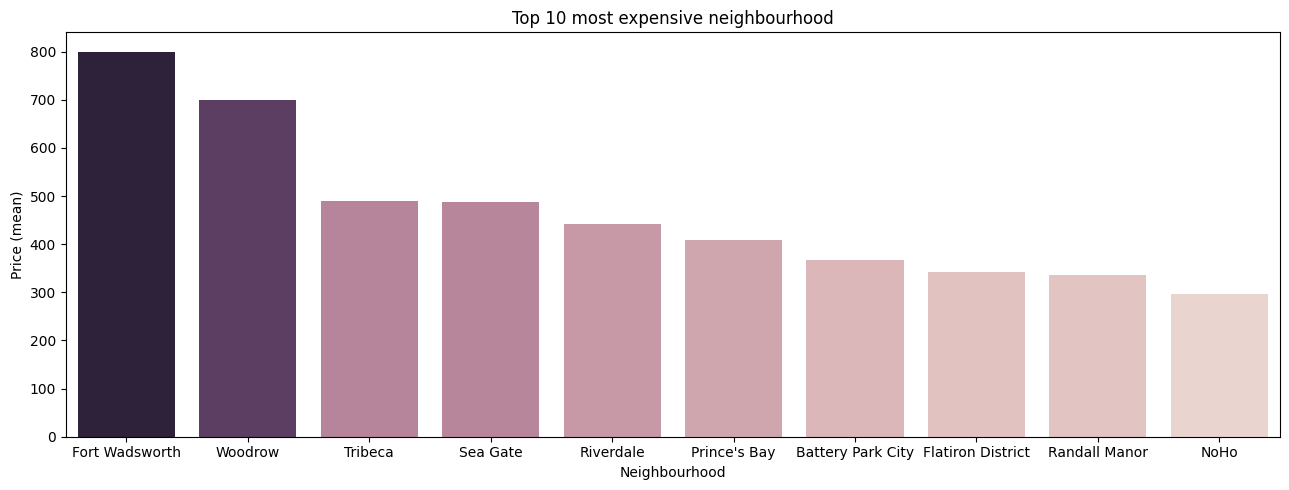

In [18]:
plt.figure(figsize=(13,5))
sns.barplot(x=top_10_neighbourhood.index, y=top_10_neighbourhood.values,hue=top_10_neighbourhood,legend=False)
plt.title("Top 10 most expensive neighbourhood")
plt.xlabel('Neighbourhood')
plt.ylabel('Price (mean)')
plt.tight_layout()
plt.show()

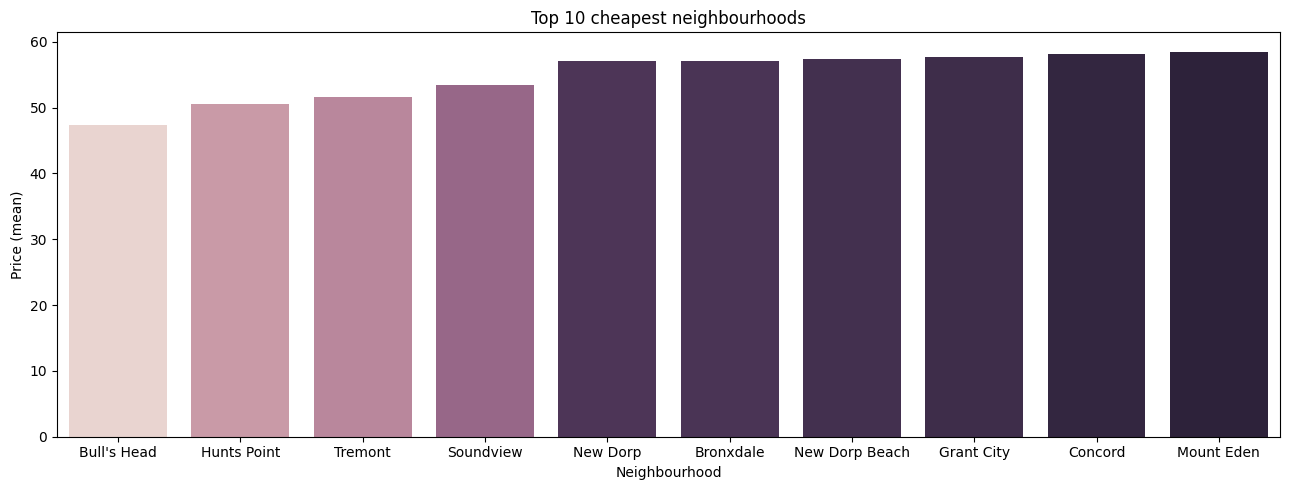

In [19]:
plt.figure(figsize=(13,5))
sns.barplot(x=bottom_10_neighbourhood.index, y=bottom_10_neighbourhood.values,hue=bottom_10_neighbourhood,legend=False)
plt.title("Top 10 cheapest neighbourhoods")
plt.xlabel('Neighbourhood')
plt.ylabel('Price (mean)')
plt.tight_layout()
plt.show()

### Folium map

In [20]:
nyc_map=folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()],zoom_start=12,tiles='cartodbpositron')

In [21]:
heat_data = df[['latitude', 'longitude']].values.tolist()
plugins.HeatMap(heat_data, radius=8, blur=10).add_to(nyc_map)

In [22]:
nyc_map.save('outputs/nyc_listings_heatmap.html')

### Categorical feature distribution

In [27]:
df.select_dtypes(include='str')

,name,neighbourhood_group,neighbourhood,room_type
0,Clean & quiet apt home by the park,Brooklyn,Kensington,Private room
1,Skylit Midtown Castle,Manhattan,Midtown,Entire home/apt
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,Private room
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,Entire home/apt
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,Entire home/apt
...,...,...,...,...
48879,Charming one bedroom - newly renovated rowhouse,Brooklyn,Bedford-Stuyvesant,Private room
48880,Affordable room in Bushwick/East Williamsburg,Brooklyn,Bushwick,Private room
48881,Sunny Studio at Historical Neighborhood,Manhattan,Harlem,Entire home/apt
48882,43rd St. Time Square-cozy single bed,Manhattan,Hell's Kitchen,Shared room


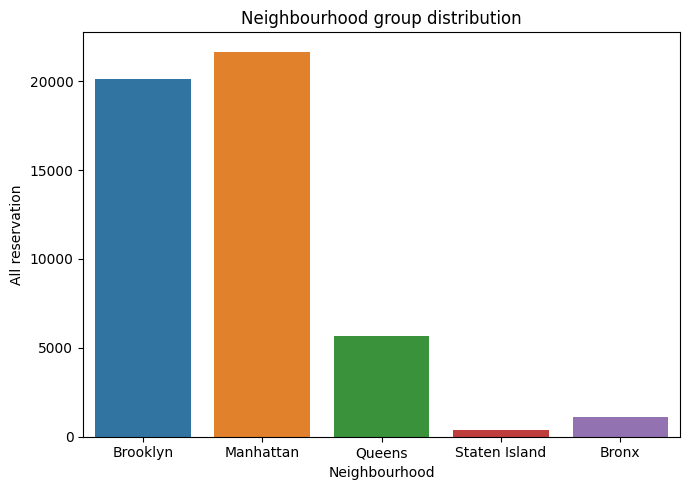

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='neighbourhood_group',hue='neighbourhood_group')
plt.title('Neighbourhood group distribution')
plt.xlabel('Neighbourhood')
plt.ylabel("All reservation")
plt.tight_layout()
plt.show()

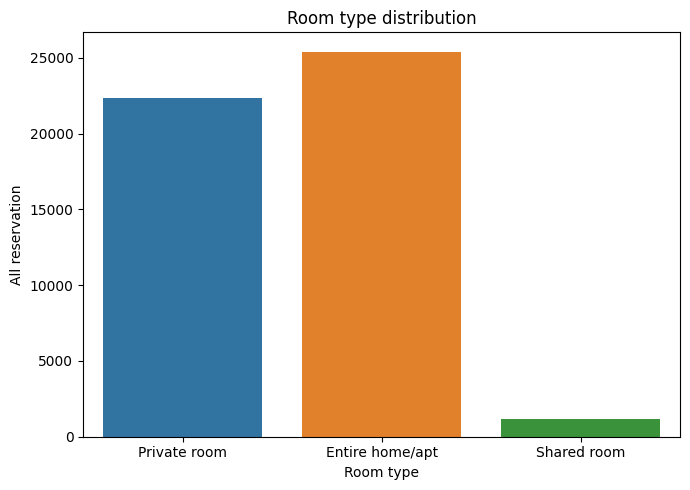

In [25]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='room_type',hue='room_type')
plt.title('Room type distribution')
plt.xlabel('Room type')
plt.ylabel("All reservation")
plt.tight_layout()
plt.show()